In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

# Load trained models
rf_model_account = joblib.load('../models/rf_model_account.pkl')
rf_model_row = joblib.load('../models/rf_model_row.pkl')

# Load test sets
X_test_account = pd.read_csv('../data/X_test_account.csv')
y_test_account = pd.read_csv('../data/y_test_account.csv').squeeze()  # squeeze turns single-col df into a Series

X_test_row = pd.read_csv('../data/X_test_row.csv')
y_test_row = pd.read_csv('../data/y_test_row.csv').squeeze()

print("Account-level test set:", X_test_account.shape)
print("Row-level test set:", X_test_row.shape)

Account-level test set: (100, 23)
Row-level test set: (1018, 32)


In [2]:
# Separate the preprocessor and classifier from the pipeline
preprocessor_acc = rf_model_account.named_steps['preprocessor']
classifier_acc = rf_model_account.named_steps['classifier']

# Transform the test data the same way the model saw it during training
X_test_account_transformed = preprocessor_acc.transform(X_test_account)

# Get feature names after one-hot encoding
numeric_cols_acc = X_test_account.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_acc = X_test_account.select_dtypes(include=['object', 'bool']).columns.tolist()

feature_names_acc = numeric_cols_acc + list(
    preprocessor_acc.named_transformers_['cat'].get_feature_names_out(categorical_cols_acc)
)

# Build the explainer and compute SHAP values
explainer_acc = shap.TreeExplainer(classifier_acc)
shap_values_acc = explainer_acc.shap_values(X_test_account_transformed)

print("SHAP values shape:", np.array(shap_values_acc).shape)

C:\Users\Ahana Basak\AppData\Local\Temp\ipykernel_29448\2835048635.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_acc = X_test_account.select_dtypes(include=['object', 'bool']).columns.tolist()


SHAP values shape: (100, 40, 2)


In [4]:
import os
os.makedirs('../outputs', exist_ok=True)

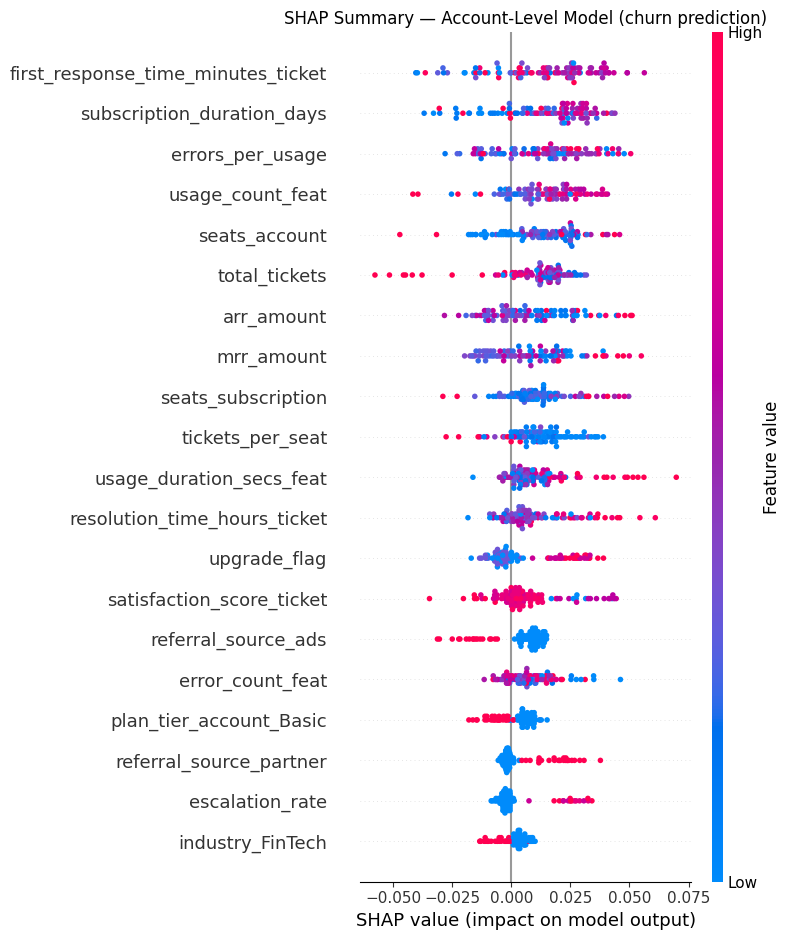

In [5]:
# shap_values_acc[:, :, 1] selects the "churned" class explanations
shap.summary_plot(
    shap_values_acc[:, :, 1], 
    X_test_account_transformed, 
    feature_names=feature_names_acc,
    show=False
)
plt.title("SHAP Summary — Account-Level Model (churn prediction)")
plt.tight_layout()
plt.savefig('../outputs/shap_summary_account.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
preprocessor_row = rf_model_row.named_steps['preprocessor']
classifier_row = rf_model_row.named_steps['classifier']

X_test_row_transformed = preprocessor_row.transform(X_test_row)

numeric_cols_row = X_test_row.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_row = X_test_row.select_dtypes(include=['object', 'bool', 'string']).columns.tolist()

feature_names_row = numeric_cols_row + list(
    preprocessor_row.named_transformers_['cat'].get_feature_names_out(categorical_cols_row)
)

explainer_row = shap.TreeExplainer(classifier_row)
shap_values_row = explainer_row.shap_values(X_test_row_transformed)

print("SHAP values shape:", np.array(shap_values_row).shape)

SHAP values shape: (1018, 56, 2)


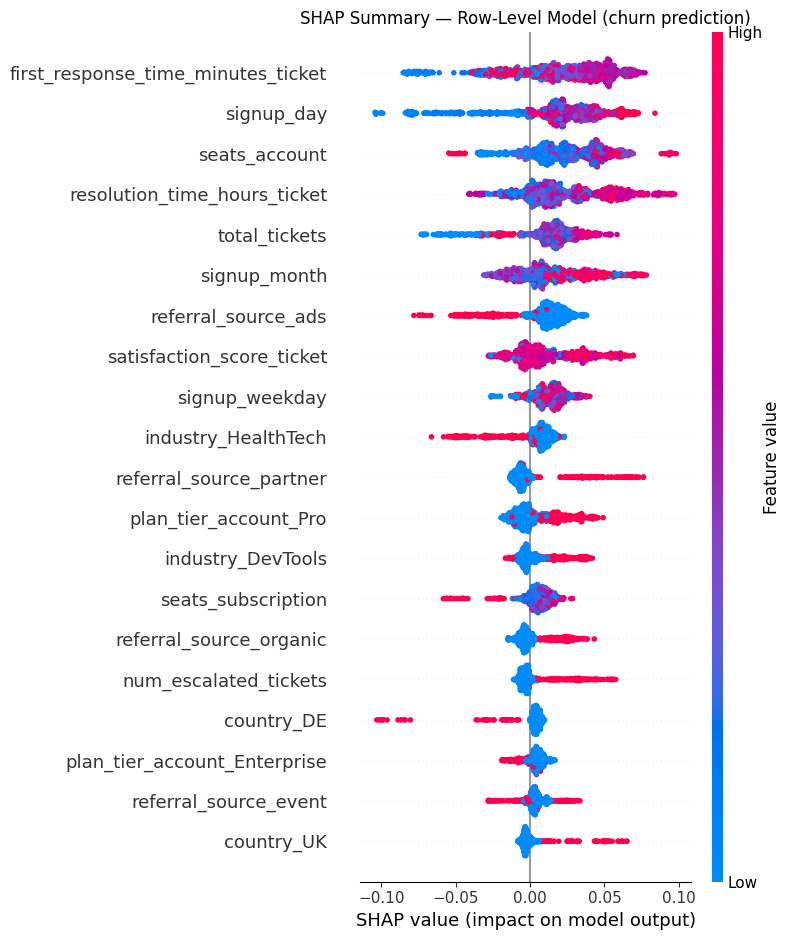

In [7]:
shap.summary_plot(
    shap_values_row[:, :, 1], 
    X_test_row_transformed, 
    feature_names=feature_names_row,
    show=False
)
plt.title("SHAP Summary — Row-Level Model (churn prediction)")
plt.tight_layout()
plt.savefig('../outputs/shap_summary_row.png', dpi=150, bbox_inches='tight')
plt.show()